In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cudf
import cuml
from cuml.svm import SVC as cuSVC
from cuml.model_selection import train_test_split as cu_train_test_split
from cuml.preprocessing import RobustScaler as cuRobustScaler
from cuml.metrics import accuracy_score as cu_accuracy
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

print(f"cuML version: {cuml.__version__}")

cuML version: 25.10.00


In [ ]:
core_path    = os.getcwd()
orbital_df = pd.read_pickle(os.path.join(core_path, 'data/lvl3/orbital_df.pkl'))

FEATURES_A = ['a_p', 'e_p', 'sin_i_p', 'g', 's']
FEATURES_B = ['a_p', 'e_p', 'sin_i_p', 'g', 's',
              'rms_a', 'rms_e', 'rms_sin_i', 'LCE']

y = orbital_df['is_family_member'].astype(int).values

print(f"Total asteroids : {len(orbital_df):,}")
print(f"Family members  : {y.sum():,}")
print(f"Background      : {(y==0).sum():,}")

Total asteroids : 1,038,241
Family members  : 230,607
Background      : 807,634


In [ ]:
# # Parameter grid
# C_values      = [0.1, 1.0, 10.0]
# kernel_values = ['linear']

# # Store all results
# grid_results = {}

In [3]:
# Split on CPU first for stratification, then move to GPU
X_a = orbital_df[FEATURES_A].values
X_b = orbital_df[FEATURES_B].values

# Stratified split
X_a_train, X_a_test, y_train, y_test = train_test_split(
    X_a, y, test_size=0.2, random_state=42, stratify=y
)
X_b_train, X_b_test, _, _ = train_test_split(
    X_b, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler_a = RobustScaler()
X_a_train_s = scaler_a.fit_transform(X_a_train)
X_a_test_s  = scaler_a.transform(X_a_test)

scaler_b = RobustScaler()
X_b_train_s = scaler_b.fit_transform(X_b_train)
X_b_test_s  = scaler_b.transform(X_b_test)

print(f"Train : {len(X_a_train_s):,}  |  Test : {len(X_a_test_s):,}")

Train : 830,592  |  Test : 207,649


In [ ]:
## BASED ON SUBSAMPLE OF THE DATASET TO SPEED UP GRID SEARCH DURING DEVELOPMENT

# from sklearn.model_selection import StratifiedShuffleSplit
# import gc
# import cupy as cp
# from sklearn.metrics import accuracy_score

# # Stratified 10% subsample for training only
# sss = StratifiedShuffleSplit(n_splits=1, test_size=0.9, random_state=42)
# subsample_idx, _ = next(sss.split(X_a_train_s, y_train))

# X_a_train_sub = X_a_train_s[subsample_idx]
# X_b_train_sub = X_b_train_s[subsample_idx]
# y_train_sub   = y_train[subsample_idx]

# print(f"Subsample size : {len(X_a_train_sub):,}")
# print(f"Class balance  : {y_train_sub.mean()*100:.1f}% family")

# C_values      = [0.1, 1.0, 10.0]
# kernel_values = ['linear']

# grid_results  = {}

# for feat_name, X_train_sub, X_test_s in [
#     ('Set_A_orbital', X_a_train_sub, X_a_test_s),
#     ('Set_B_full',    X_b_train_sub, X_b_test_s),
# ]:
#     print(f"\n{'='*60}")
#     print(f"Feature {feat_name}")
#     print(f"{'='*60}")

#     best_f1     = -1
#     best_params = None
#     best_res    = None

#     for kernel in kernel_values:
#         for C in C_values:
#             print(f"\n  Trying kernel={kernel}, C={C}...")

#             X_tr_gpu = cudf.DataFrame(X_train_sub.astype(np.float32))
#             X_te_gpu = cudf.DataFrame(X_test_s.astype(np.float32))
#             y_tr_gpu = cudf.Series(y_train_sub.astype(np.int32))

#             svm = cuSVC(
#                 C=C,
#                 kernel=kernel,
#                 class_weight='balanced',
#                 probability=False,
#                 random_state=42
#             )

#             svm.fit(X_tr_gpu, y_tr_gpu)
#             y_pred_gpu  = svm.predict(X_te_gpu)
#             y_score_gpu = svm.decision_function(X_te_gpu)

#             y_pred  = cp.asnumpy(y_pred_gpu.values).astype(int)
#             y_score = cp.asnumpy(y_score_gpu.values)

#             acc  = accuracy_score(y_test, y_pred)
#             prec = precision_score(y_test, y_pred)
#             rec  = recall_score(y_test, y_pred)
#             f1   = f1_score(y_test, y_pred)
#             auc  = roc_auc_score(y_test, y_score)

#             print(f"    Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUC={auc:.4f}")

#             grid_results[f"{feat_name}_k{kernel}_C{C}"] = {
#                 'feat_name': feat_name, 'kernel': kernel, 'C': C,
#                 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc,
#                 'y_pred': y_pred, 'y_score': y_score
#             }

#             if f1 > best_f1:
#                 best_f1     = f1
#                 best_params = {'kernel': kernel, 'C': C}
#                 best_res    = grid_results[f"{feat_name}_k{kernel}_C{C}"]

#             del svm, X_tr_gpu, X_te_gpu, y_tr_gpu
#             gc.collect()
#             cp.get_default_memory_pool().free_all_blocks()

#     print(f"\n  Best params for {feat_name}: {best_params} → F1={best_f1:.4f}")
#     grid_results[f"{feat_name}_best"] = best_res

In [4]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedShuffleSplit
import gc

# 10% stratified subsample for training
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.9, random_state=42)
subsample_idx, _ = next(sss.split(X_a_train_s, y_train))

X_a_train_sub = X_a_train_s[subsample_idx]
X_b_train_sub = X_b_train_s[subsample_idx]
y_train_sub   = y_train[subsample_idx]

print(f"Subsample size : {len(X_a_train_sub):,}")

C_values      = [0.1, 1.0, 10.0]
kernel_values = ['linear', 'rbf']
grid_results  = {}

for feat_name, X_train_sub, X_test_s in [
    ('Set_A_orbital', X_a_train_sub, X_a_test_s),
    ('Set_B_full',    X_b_train_sub, X_b_test_s),
]:
    print(f"\n{'='*55}")
    print(f"Feature {feat_name}")
    print(f"{'='*55}")

    best_f1     = -1
    best_params = None
    best_res    = None

    for kernel in kernel_values:
        for C in C_values:
            print(f"\n  Trying kernel={kernel}, C={C}...")

            if kernel == 'linear':
                # LinearSVC is faster for linear kernel
                svm = LinearSVC(
                    C=C,
                    class_weight='balanced',
                    max_iter=2000,
                    random_state=42
                )
                clf = CalibratedClassifierCV(svm, cv=3)
            else:
                # Full SVC for RBF
                clf = SVC(
                    C=C,
                    kernel='rbf',
                    class_weight='balanced',
                    probability=True,
                    random_state=42,
                    cache_size=2000   # 2GB cache — speeds up RBF
                )

            clf.fit(X_train_sub, y_train_sub)

            y_pred  = clf.predict(X_test_s)
            y_proba = clf.predict_proba(X_test_s)[:, 1]

            acc  = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred)
            rec  = recall_score(y_test, y_pred)
            f1   = f1_score(y_test, y_pred)
            auc  = roc_auc_score(y_test, y_proba)

            print(f"    Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUC={auc:.4f}")

            grid_results[f"{feat_name}_k{kernel}_C{C}"] = {
                'feat_name': feat_name, 'kernel': kernel, 'C': C,
                'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc,
                'y_pred': y_pred, 'y_proba': y_proba
            }

            if f1 > best_f1:
                best_f1     = f1
                best_params = {'kernel': kernel, 'C': C}
                best_res    = grid_results[f"{feat_name}_k{kernel}_C{C}"]

            del clf
            gc.collect()

    print(f"\n  Best for {feat_name}: {best_params} → F1={best_f1:.4f}")
    grid_results[f"{feat_name}_best"] = best_res

Subsample size : 83,059

Feature Set_A_orbital

  Trying kernel=linear, C=0.1...
    Acc=0.7775 | Prec=0.0408 | Rec=0.0001 | F1=0.0002 | AUC=0.6125

  Trying kernel=linear, C=1.0...
    Acc=0.7774 | Prec=0.0396 | Rec=0.0001 | F1=0.0002 | AUC=0.6125

  Trying kernel=linear, C=10.0...
    Acc=0.7774 | Prec=0.0396 | Rec=0.0001 | F1=0.0002 | AUC=0.6125

  Trying kernel=rbf, C=0.1...
    Acc=0.7277 | Prec=0.4340 | Rec=0.7429 | F1=0.5479 | AUC=0.8110

  Trying kernel=rbf, C=1.0...
    Acc=0.7390 | Prec=0.4514 | Rec=0.8130 | F1=0.5805 | AUC=0.8498

  Trying kernel=rbf, C=10.0...
    Acc=0.7642 | Prec=0.4825 | Rec=0.8531 | F1=0.6164 | AUC=0.8857

  Best for Set_A_orbital: {'kernel': 'rbf', 'C': 10.0} → F1=0.6164

Feature Set_B_full

  Trying kernel=linear, C=0.1...
    Acc=0.7774 | Prec=0.0413 | Rec=0.0001 | F1=0.0002 | AUC=0.6273

  Trying kernel=linear, C=1.0...
    Acc=0.7774 | Prec=0.0488 | Rec=0.0001 | F1=0.0003 | AUC=0.6273

  Trying kernel=linear, C=10.0...
    Acc=0.7774 | Prec=0.0488 

In [5]:
print(f"\n{'='*80}")
print(f"{'SVM Grid Search — All Results':^80}")
print(f"{'='*80}")
print(f"{'Config':<35} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC':>8}")
print(f"{'-'*80}")

for key, res in grid_results.items():
    if '_best' in key:
        continue
    print(f"{key:<35} {res['acc']:>8.4f} {res['prec']:>8.4f} "
          f"{res['rec']:>8.4f} {res['f1']:>8.4f} {res['auc']:>8.4f}")


                         SVM Grid Search — All Results                          
Config                                   Acc     Prec      Rec       F1      AUC
--------------------------------------------------------------------------------
Set_A_orbital_klinear_C0.1            0.7775   0.0408   0.0001   0.0002   0.6125
Set_A_orbital_klinear_C1.0            0.7774   0.0396   0.0001   0.0002   0.6125
Set_A_orbital_klinear_C10.0           0.7774   0.0396   0.0001   0.0002   0.6125
Set_A_orbital_krbf_C0.1               0.7277   0.4340   0.7429   0.5479   0.8110
Set_A_orbital_krbf_C1.0               0.7390   0.4514   0.8130   0.5805   0.8498
Set_A_orbital_krbf_C10.0              0.7642   0.4825   0.8531   0.6164   0.8857
Set_B_full_klinear_C0.1               0.7774   0.0413   0.0001   0.0002   0.6273
Set_B_full_klinear_C1.0               0.7774   0.0488   0.0001   0.0003   0.6273
Set_B_full_klinear_C10.0              0.7774   0.0488   0.0001   0.0003   0.6273
Set_B_full_krbf_C0.1       

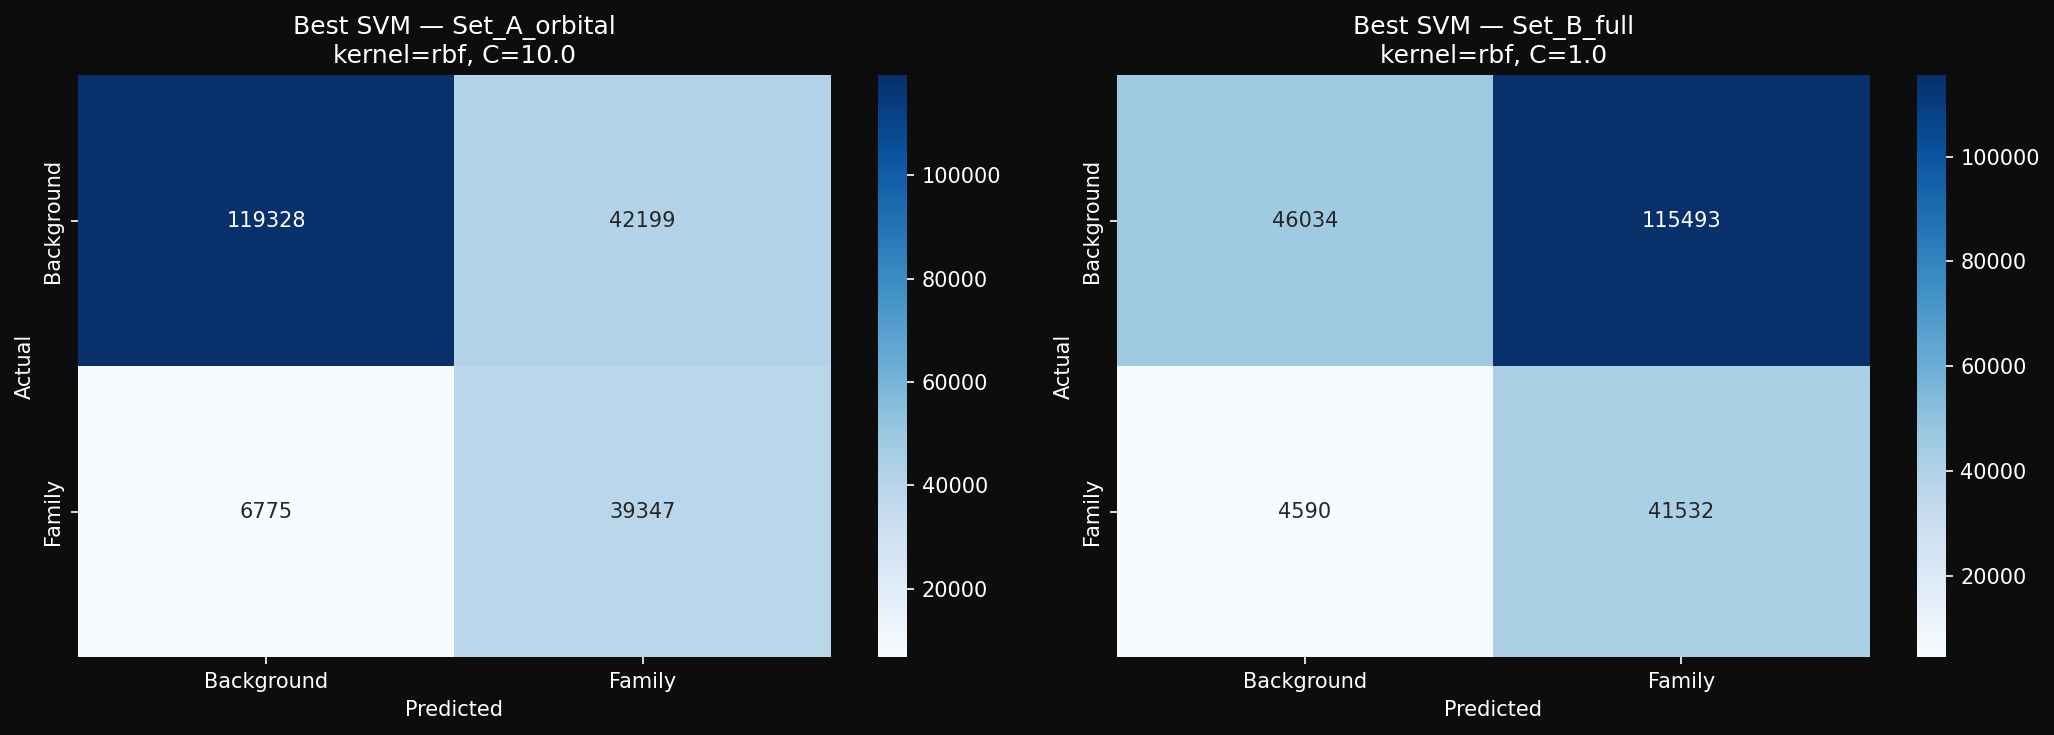

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat_name in zip(axes, ['Set_A_orbital', 'Set_B_full']):
    res = grid_results[f"{feat_name}_best"]
    cm  = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Background', 'Family'],
                yticklabels=['Background', 'Family'],
                ax=ax, cbar=True)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f"Best SVM — {feat_name}\n"
                 f"kernel={res['kernel']}, C={res['C']}")

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05a_ii_svm_confusion.png'), dpi=200, bbox_inches='tight')
plt.show()

In [8]:
# Load RF results
with open(os.path.join('data', 'results', 'classification_results', '06a_i_binary_rf_results.pkl'), 'rb') as f:
    rf_results = pickle.load(f)

print(f"\n{'='*75}")
print(f"{'Binary Classification Comparison — RF vs Best SVM':^75}")
print(f"{'='*75}")
print(f"{'Model':<30} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC':>8}")
print(f"{'-'*75}")

# RF results
for feat_name, res in rf_results.items():
    print(f"{'RF_'+feat_name:<30} {res['acc']:>8.4f} {res['prec']:>8.4f} "
          f"{res['rec']:>8.4f} {res['f1']:>8.4f} {res['auc']:>8.4f}")

# Best SVM results
for feat_name in ['Set_A_orbital', 'Set_B_full']:
    res = grid_results[f"{feat_name}_best"]
    print(f"{'SVM_'+feat_name:<30} {res['acc']:>8.4f} {res['prec']:>8.4f} "
          f"{res['rec']:>8.4f} {res['f1']:>8.4f} {res['auc']:>8.4f}")


             Binary Classification Comparison — RF vs Best SVM             
Model                               Acc     Prec      Rec       F1      AUC
---------------------------------------------------------------------------
RF_Set_A_orbital                 0.9712   0.9078   0.9686   0.9372   0.9960
RF_Set_B_full                    0.9659   0.8965   0.9572   0.9259   0.9944
SVM_Set_A_orbital                0.7642   0.4825   0.8531   0.6164   0.8857
SVM_Set_B_full                   0.4217   0.2645   0.9005   0.4089   0.6198


In [10]:
save_dict = {
    key: {k: v for k, v in res.items() if k != 'model'}
    for key, res in grid_results.items()
}

with open(os.path.join('data', 'results', 'classification_results', '06a_ii_binary_svm_results.pkl'), 'wb') as f:
    pickle.dump(save_dict, f)

print("Saved → data/results/06a_ii_binary_svm_results.pkl")

Saved → data/results/06a_ii_binary_svm_results.pkl
